# Линейная регрессия

# Задание 1

Считаем наш датасет: файл, в котором содержится информация об объеме батарейки телефона (мАч) и его цене. 

In [2]:
import pandas as pd

data = pd.read_csv('phones.csv')

Посмотрим на данные, узнаем, сколько их.

In [3]:
data.head()

,battery,price
0,1879,18811
1,4484,44780
2,3121,31197
3,4409,44174
4,4668,46688


In [4]:
data.shape

(999, 2)

### Разобьем данные на тренировочную и тестовую выборки

In [6]:
from sklearn.model_selection import train_test_split

X = data[['battery']] # у нас всего один признак, но sklearn ждет от нас матрицу, поэтому мы не можем взять просто один столбец
y = data.price

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# Проверим, как работает функция линейной регрессии из sklearn

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()

model.fit(Xtrain, ytrain) # обучение модели

coef = float(model.coef_.item()) # веса при признаках
intercept = model.intercept_ # свободный коэффициент (w0)
print(f'''
Вес при признаке "размер батарейки": {coef:.3f},
Свободный коэффициент:  {intercept:.3f}''')


Вес при признаке "размер батарейки": 9.999,
Свободный коэффициент:  5.478


$ Weight = w_0 + w_1\cdot Height$

$ Weight = 5.478 + 9.999\cdot Height$

Возьмем любую пару "объем батарейки" и "цена" из датафрейма. Проверим, что если подставить их в нашу формулу, получится что-то похожее

In [8]:
x = data['battery'][0]
y = data['price'][0]

In [9]:
y

18811

In [10]:
intercept + x * coef

18792.77288207743

In [11]:
pred_test = model.predict(Xtest) # делаем предсказание

mean_squared_error(pred_test, ytest) ** 0.5 # ошибка примерно 60 рублей

61.22980596631552

In [12]:
pred_train = model.predict(Xtrain)

mean_squared_error(pred_train, ytrain) ** 0.5

57.82959463391074

Модель не переобучена. Как мы это поняли?

### Это тот редкий случай, когда мы можем изобразить график с линейной регрессией.

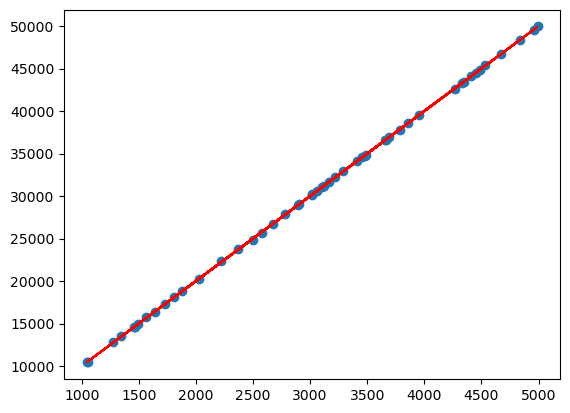

In [13]:
from matplotlib import pylab as plt

plt.scatter(data['battery'][:50], data['price'][:50])

plt.plot(X[:50], coef * X[:50] + intercept, 'r')
plt.show()

# Задание 2

Поработаем с датасетом Medical insurance costs.

In [14]:
data = pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [19]:
data.sex = data.sex.apply(lambda x: 0 if x == 'male' else 1)
data.smoker = data.smoker.apply(lambda x: 0 if x == 'no' else 1)
data = pd.get_dummies(data, 'region', drop_first=True) 

In [20]:
data.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,1,1725.55230,False,True,False
2,28,1,33.000,3,1,4449.46200,False,True,False
3,33,1,22.705,0,1,21984.47061,True,False,False
4,32,1,28.880,0,1,3866.85520,True,False,False


In [21]:
y = data.charges
X = data.drop('charges', axis=1)

Разбейте данные на train и test. Обучите линейную регрессию на train и сделайте предсказание на train и test.

In [22]:
# your code here
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(Xtrain, ytrain) # обучение модели
pred_train = model.predict(Xtrain)
pred_test = model.predict(Xtest)

Выведите MSE на train и на test. Выведите RMSE. На сколько в среднем мы ошибаемся на train и test? Модель переобучена, недообучена или все ок?

In [23]:
mean_squared_error(pred_test, ytest) ** 0.5 

11422.48910912473

In [24]:
mean_squared_error(pred_train, ytrain) ** 0.5

11315.00906991806

Нарисуем матрицу корреляций признаков.

<AxesSubplot: >

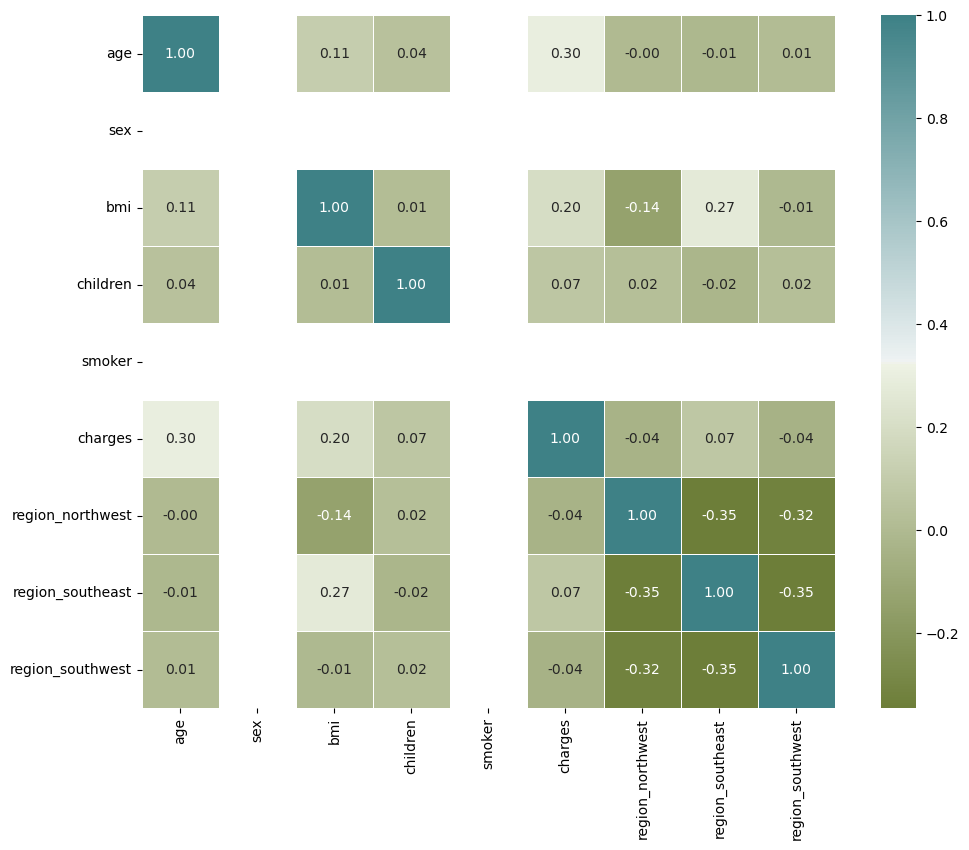

In [26]:
import seaborn as sns
import numpy as np

plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)

Мы можем удалять признаки

In [27]:
del data['region_northwest']

Создавать новые из уже существующих

In [28]:
data['smoker'] = data['smoker'] ** 2

Посмотрим на новую матрицу объект-признак

In [29]:
y = data.charges
X = data.drop('charges', axis=1)

X.head()

,age,sex,bmi,children,smoker,region_southeast,region_southwest
0,19,1,27.900,0,1,False,True
1,18,1,33.770,1,1,True,False
2,28,1,33.000,3,1,True,False
3,33,1,22.705,0,1,False,False
4,32,1,28.880,0,1,False,False


In [30]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(Xtrain, ytrain) # обучение модели
pred_train = model.predict(Xtrain)
pred_test = model.predict(Xtest)
print(mean_squared_error(pred_test, ytest) ** 0.5, mean_squared_error(pred_train, ytrain) ** 0.5)

11428.09790640582 11321.032232054917


Можем изучить каждый признак в отдельности, изучить его распределение с ЦП

age


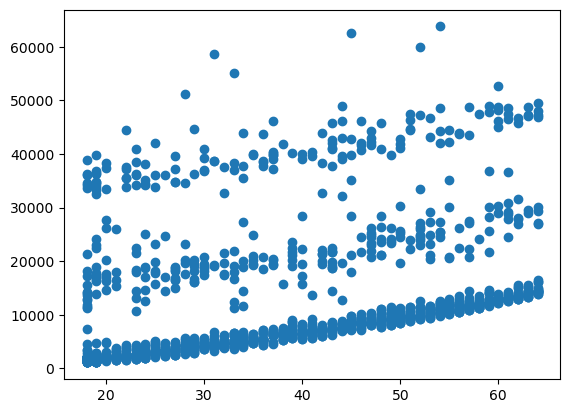

sex


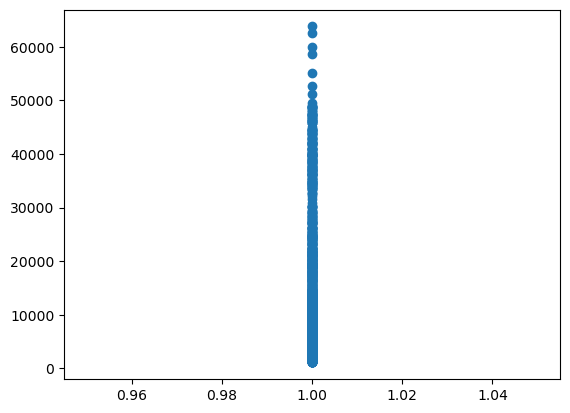

bmi


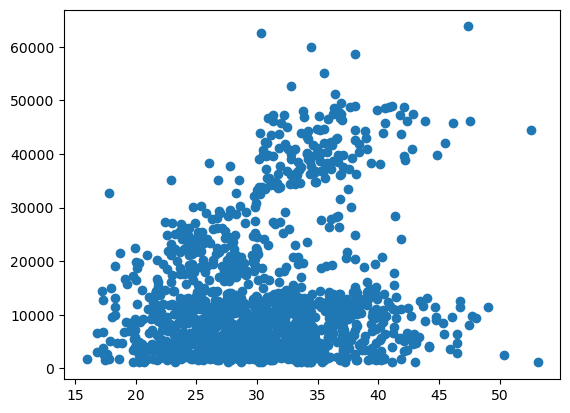

children


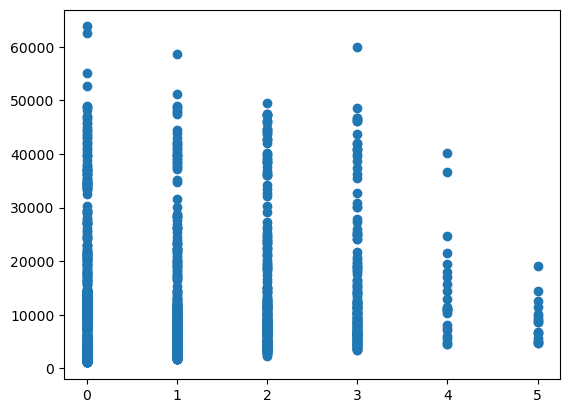

smoker


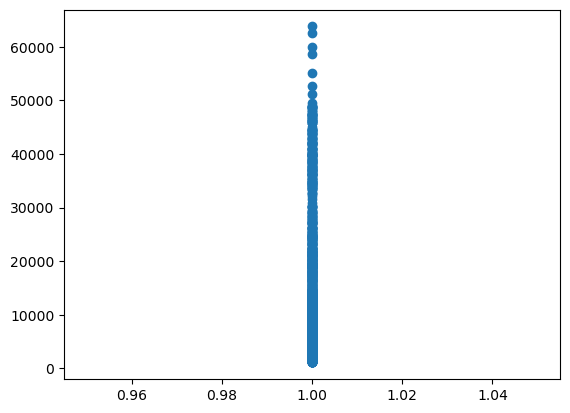

region_southeast


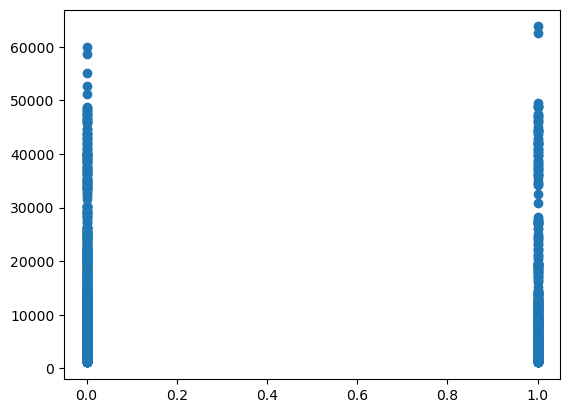

region_southwest


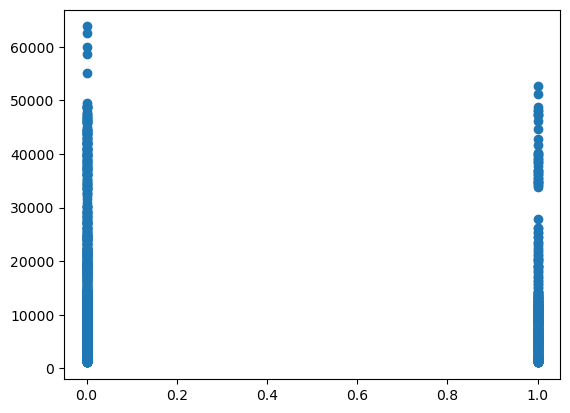

In [31]:
for c in data.columns:
    if c != 'charges':
        print(c)
        plt.scatter(data[c], data['charges'])
        plt.show()

# Задание 3. 

Возьмем датасет про доставку еды: в нашем датасете есть базовая информация о доставке (на каком транспортном средстве ехал курьер, было это утром, днем или вечером, в какую погоду и так далее). Проверьте, нет ли в датасете пропущенных ячеек: scikit-learn не умеет работать с отсутствующими данными, их нужно убрать или каким-либо образом заполнить. Используйте One Hot Encoding для категориальных признаков. Обучите линейную регрессию для предсказания времени доставки и посчитайте, на сколько минут в среднем ошибается ваша модель?

In [33]:
data = pd.read_csv('/home/mountains_owner/Рабочий стол/учеба/прога/машинка/Food_Delivery_Times.csv')
data.isna().any()

Order_ID                  False
Distance_km               False
Weather                    True
Traffic_Level              True
Time_of_Day                True
Vehicle_Type              False
Preparation_Time_min      False
Courier_Experience_yrs     True
Delivery_Time_min         False
dtype: bool

In [34]:
data.dropna(inplace=True)
data

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [38]:
data['Vehicle_Type'].unique()

array(['Scooter', 'Bike', 'Car'], dtype=object)

In [39]:
data.drop('Order_ID', axis = 1, inplace = True)

In [40]:
data = pd.get_dummies(data, 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', drop_first=True) 

<AxesSubplot: >

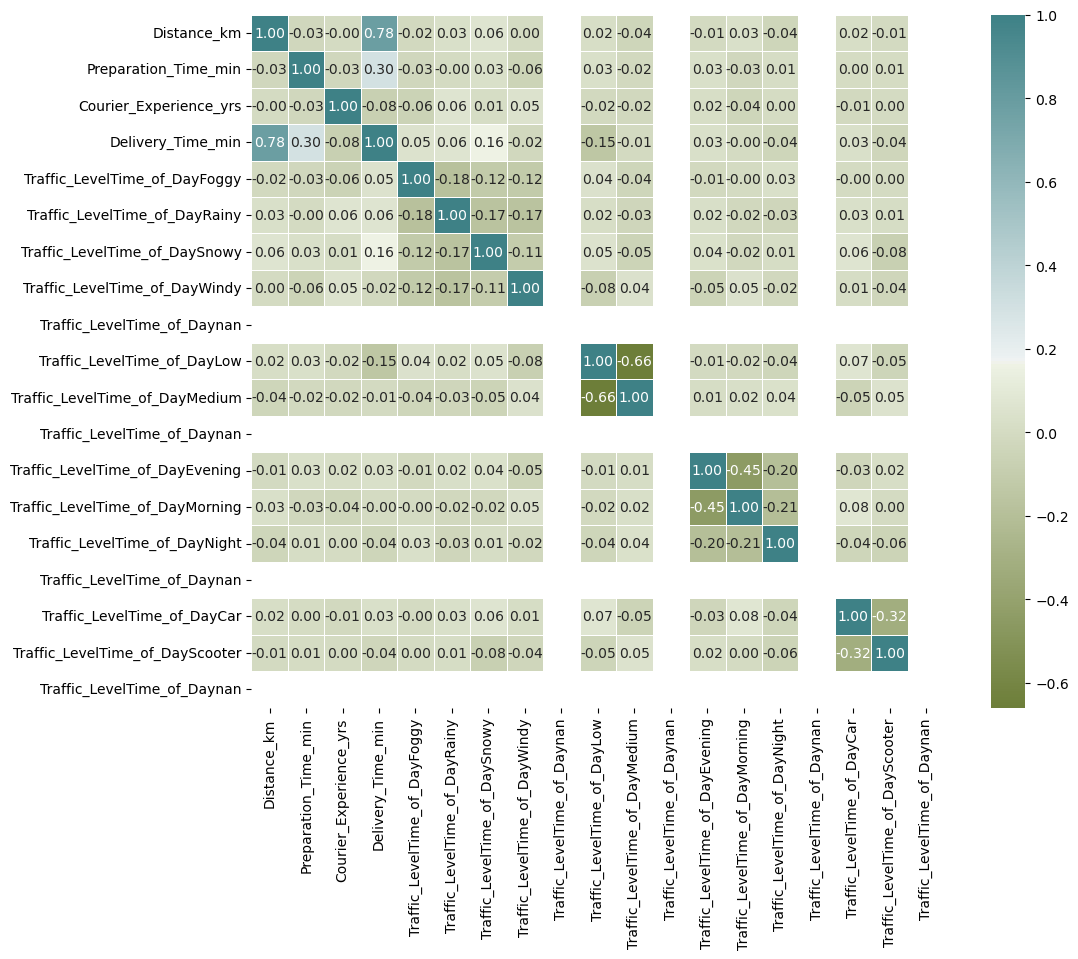

In [ ]:
plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)

# сильно кореллирующих признаков нет

In [49]:
X = data.drop('Delivery_Time_min', axis = 1)
y = data['Delivery_Time_min']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
model = LinearRegression()
model.fit(Xtrain, ytrain) 
pred_train = model.predict(Xtrain)
pred_test = model.predict(Xtest)

In [47]:
mean_squared_error(pred_train, ytrain) ** 0.5 

10.332022750581391

In [45]:
mean_squared_error(pred_test, ytest) ** 0.5 
# модель не переобучена, ошибка на тесте даже меньше, чем на трейне

8.273316732781124